In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt
import zipfile
import io

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from keras.models import Sequential
from keras.layers import Dense, Dropout
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from statsmodels.tsa.arima.model import ARIMA
from keras.regularizers import l2
from keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import GridSearchCV, RepeatedKFold

from scipy.integrate import odeint
from datetime import datetime, timedelta

In [ ]:
df = pd.read_csv("datos_combinados_por_medicamento.csv", encoding='latin1')
df


,FechaHora,Descripcion,num_casos,num_hosp,num_uci,num_def,num_recu,num_susc,VentasDiarias,VentasTotalesDiarias,IdProducto
0,2020-01-01,ALCOHOL DESINFECTANTE,0,0,0,0,0.0,959801.0,1,76,1
1,2020-01-01,APIRETAL,0,0,0,0,0.0,959801.0,7,76,2
2,2020-01-01,DALSY,0,0,0,0,0.0,959801.0,3,76,3
3,2020-01-01,ENANTYUM,0,0,0,0,0.0,959801.0,12,76,4
4,2020-01-01,FLUIMUCIL,0,0,0,0,0.0,959801.0,8,76,6
...,...,...,...,...,...,...,...,...,...,...,...
9363,2022-03-27,MASCARILLA,288,6,0,2,551.0,958960.0,165,326,10
9364,2022-03-27,NOLOTIL,288,6,0,2,551.0,958960.0,1,326,11
9365,2022-03-27,ORFIDAL,288,6,0,2,551.0,958960.0,2,326,12
9366,2022-03-27,PARACETAMOL,288,6,0,2,551.0,958960.0,33,326,13


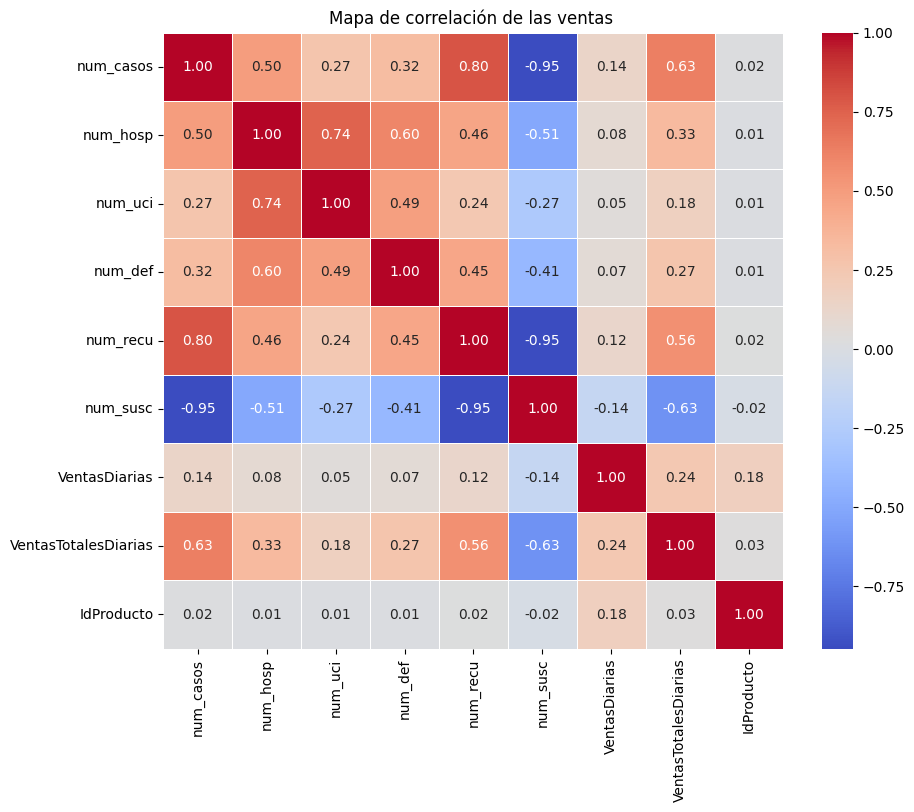

In [ ]:

datos_numericos = df.select_dtypes(include=['float64', 'int64'])

correlation_matrix = datos_numericos.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Mapa de correlación de las ventas ')
plt.show()

<ipython-input-4-8d21a8f8b040>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlation_df.index, y='Correlation', data=correlation_df, palette='coolwarm')


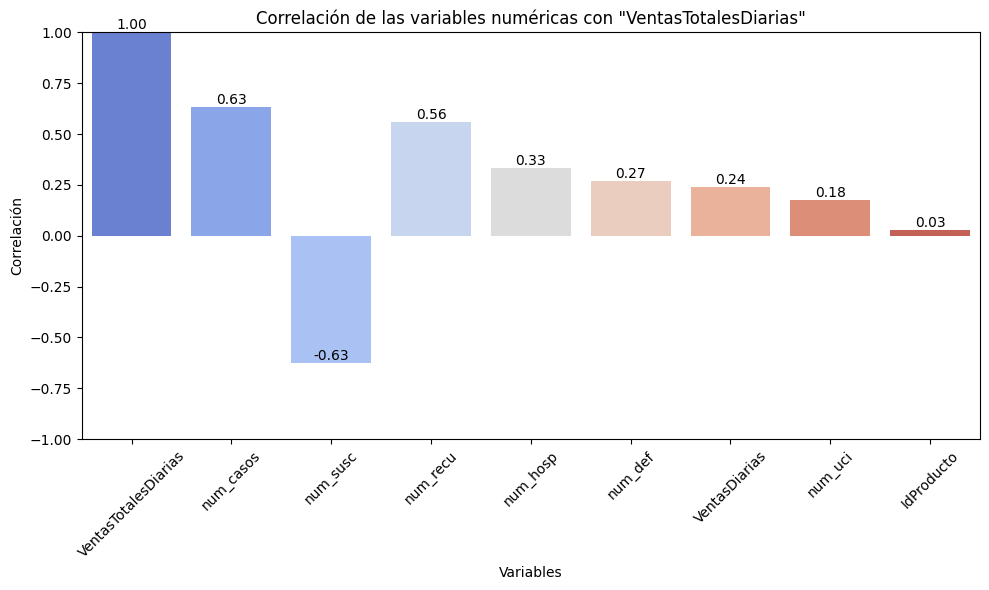

In [ ]:
variable_interes = 'VentasTotalesDiarias'

datos_numericos = df.select_dtypes(include=['float64', 'int64'])

correlation_with_target = datos_numericos.corrwith(df[variable_interes])

correlation_df = pd.DataFrame(correlation_with_target, columns=['Correlation'])

correlation_df['Abs Correlation'] = correlation_df['Correlation'].abs()
correlation_df = correlation_df.sort_values(by='Abs Correlation', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=correlation_df.index, y='Correlation', data=correlation_df, palette='coolwarm')
plt.title(f'Correlación de las variables numéricas con "{variable_interes}"')
plt.xlabel('Variables')
plt.ylabel('Correlación')
plt.xticks(rotation=45)
plt.ylim(-1, 1)
for index, value in enumerate(correlation_df['Correlation']):
    plt.text(index, value, f'{value:.2f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()


#MODELAR RELACION

Regresión lineal simple


In [ ]:
X_single = df[['num_casos']]
y = df['VentasDiarias']

X_train, X_test, y_train, y_test = train_test_split(X_single, y, test_size=0.2, random_state=42)


In [ ]:
linear_model_simple = LinearRegression()
linear_model_simple.fit(X_train, y_train)
y_pred_simple = linear_model_simple.predict(X_test)
mse_simple = mean_squared_error(y_test, y_pred_simple)
r2_simple = r2_score(y_test, y_pred_simple)

print(f'Regresión Lineal Simple: MSE={mse_simple:.4f}, R2={r2_simple:.4f}')

Regresión Lineal Simple: MSE=37556.9156, R2=0.0249


## nueva division de test y prueba

In [ ]:
df['FechaHora'] = pd.to_datetime(df['FechaHora'])

df['Year'] = df['FechaHora'].dt.year
df['Month'] = df['FechaHora'].dt.month
df['Day'] = df['FechaHora'].dt.day


X = df[['num_casos', 'num_def', 'num_recu', 'num_susc', 'IdProducto', 'Year', 'Month', 'Day']]
y = df['VentasDiarias']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Regresión polinómica

In [ ]:
def fit_polynomial_regression(X_train, y_train, X_test, y_test, degrees):
    param_grid = {'poly__degree': degrees}
    poly = PolynomialFeatures()
    poly_model = LinearRegression()
    poly_pipe = Pipeline([('poly', poly), ('linear', poly_model)])

    grid_search = GridSearchCV(poly_pipe, param_grid, cv=RepeatedKFold(n_splits=5, n_repeats=1), scoring='neg_mean_squared_error', n_jobs=-1)
    grid_search.fit(X_train, y_train)

    best_degree = grid_search.best_params_['poly__degree']
    best_model = grid_search.best_estimator_

    y_pred = best_model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    return best_degree, mse, r2

degrees = [1, 2, 3, 4, 5]
best_degree, mse_poly, r2_poly = fit_polynomial_regression(X_train, y_train, X_test, y_test, degrees)

print(f'Mejor grado del polinomio encontrado: {best_degree}')
print(f'Regresión Polinómica: MSE={mse_poly:.4f}, R2={r2_poly:.4f}')

/usr/local/lib/python3.10/dist-packages/joblib/externals/loky/backend/fork_exec.py:38: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid = os.fork()


Mejor grado del polinomio encontrado: 2
Regresión Polinómica: MSE=34378.8840, R2=0.1074


Random forest

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(), [1])
    ],
    remainder='passthrough'
)

rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

param_grid = {
    'regressor__n_estimators': [ 100, 150],
    'regressor__max_depth': [None, 20, 30],
    'regressor__min_samples_split': [5, 10],
    'regressor__min_samples_leaf': [2, 4]
}

grid_search = GridSearchCV(rf_model, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_rf_model = grid_search.best_estimator_

y_pred_rf = best_rf_model.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f'Random Forest con mejores parámetros: MSE={mse_rf:.4f}, R2={r2_rf:.4f}')
print(f'Mejores parámetros encontrados: {best_params}')

Random Forest con mejores parámetros: MSE=10811.1756, R2=0.7193
Mejores parámetros encontrados: {'regressor__max_depth': 20, 'regressor__min_samples_leaf': 4, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 150}


Gradient Boosting

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(), ['IdProducto'])
    ],
    remainder='passthrough'
)
gb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(random_state=42))
])

param_grid = {
    'regressor__n_estimators': [100, 300],
    'regressor__learning_rate': [0.01, 0.05],
    'regressor__max_depth': [3, 7],
    'regressor__subsample': [0.8, 1.0],
    'regressor__min_samples_split': [2, 10]
}

grid_search = GridSearchCV(estimator=gb_model, param_grid=param_grid, cv=5, n_jobs=-1, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

y_pred_gb = best_model.predict(X_test)

mse_gb = mean_squared_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print(f'Best Model: {best_model}')
print(f'Best Model Mean Squared Error: {mse_gb}')
print(f'Best Model R2: {r2_gb}')


Best Model: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat', OneHotEncoder(),
                                                  ['IdProducto'])])),
                ('regressor',
                 GradientBoostingRegressor(learning_rate=0.05, n_estimators=300,
                                           random_state=42))])
Best Model Mean Squared Error: 10176.933806420268
Best Model R2: 0.7357653365186698


Redes Neuronales

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

nn_model = Sequential()
nn_model.add(Dense(64, input_dim=X_train_scaled.shape[1], activation='relu', kernel_regularizer=l2(0.001)))
nn_model.add(Dropout(0.2))
nn_model.add(Dense(32, activation='relu', kernel_regularizer=l2(0.001)))
nn_model.add(Dense(1, activation='linear'))

nn_model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

history = nn_model.fit(X_train_scaled, y_train, epochs=200, batch_size=32, verbose=0, validation_data=(X_test_scaled, y_test))

y_pred_nn = nn_model.predict(X_test_scaled)
mse_nn = mean_squared_error(y_test, y_pred_nn)
r2_nn = r2_score(y_test, y_pred_nn)

print(f'Redes Neuronales con Regularización L2 y Dropout: MSE={mse_nn:.4f}, R2={r2_nn:.4f}')


59/59 [==============================] - 0s 2ms/step
Redes Neuronales con Regularización L2 y Dropout: MSE=13125.3523, R2=0.6592


#Series temporales

ARIMA

In [ ]:
medicamentos = df['Descripcion'].unique()
series_dict = {med: df[df['Descripcion'] == med]['VentasDiarias'] for med in medicamentos}


In [ ]:
def fit_arima(series):
    series = series.astype(float)
    model = ARIMA(series, order=(5, 1, 0))
    model_fit = model.fit()
    return model_fit

arima_results = {med: fit_arima(series) for med, series in series_dict.items()}

def calculate_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return mse, r2

arima_mse_list = []
arima_r2_list = []

for med, result in arima_results.items():
    y_true = series_dict[med]
    y_pred = result.predict(start=0, end=len(y_true)-1, dynamic=False)
    mse, r2 = calculate_metrics(y_true, y_pred)
    arima_mse_list.append(mse)
    arima_r2_list.append(r2)

mean_mse_arima = np.mean(arima_mse_list)
mean_r2_arima = np.mean(arima_r2_list)

print(f'Media ARIMA: MSE={mean_mse_arima:.4f}, R²={mean_r2_arima:.4f}')


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dat

Media ARIMA: MSE=11386.1569, R²=0.2540


ARIMAX

In [ ]:
arimax_results = {}
arimax_mse_list = []
arimax_r2_list = []

for med in medicamentos:
    series = df[df['Descripcion'] == med]
    exog = series[['num_casos']]
    y = series['VentasDiarias']
    model = sm.tsa.ARIMA(y, exog=exog, order=(5, 1, 0))
    model_fit = model.fit()
    arimax_results[med] = model_fit
    y_pred = model_fit.predict(start=0, end=len(y)-1, exog=exog, dynamic=False)
    mse, r2 = calculate_metrics(y, y_pred)
    arimax_mse_list.append(mse)
    arimax_r2_list.append(r2)
mean_mse_arimax = np.mean(arimax_mse_list)
mean_r2_arimax = np.mean(arimax_r2_list)

print(f'Media ARIMAX: MSE={mean_mse_arimax:.4f}, R²={mean_r2_arimax:.4f}')

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dat

Media ARIMAX: MSE=11291.2684, R²=0.2577


#Comparacion modelos

In [ ]:
print(f'Regresión Lineal Simple: MSE={mse_simple:.4f}, R2={r2_simple:.4f}')
print(f'Regresión Polinómica: MSE={mse_poly:.4f}, R2={r2_poly:.4f}')
print(f'Random Forest: MSE={mse_rf:.4f}, R2={r2_rf:.4f}')
print(f'Gradient Boosting: MSE={mse_gb:.4f}, R2={r2_gb:.4f}')
print(f'Redes Neuronales: MSE={mse_nn:.4f}, R2={r2_nn:.4f}')
print(f'ARIMA: MSE={mean_mse_arima:.4f}, R²={mean_r2_arima:.4f}')
print(f'ARIMAX: MSE={mean_mse_arimax:.4f}, R²={mean_r2_arimax:.4f}')

Regresión Lineal Simple: MSE=37556.9156, R2=0.0249
Regresión Polinómica: MSE=34378.8840, R2=0.1074
Random Forest: MSE=10811.1756, R2=0.7193
Gradient Boosting: MSE=10176.9338, R2=0.7358
Redes Neuronales: MSE=13125.3523, R2=0.6592
ARIMA: MSE=11386.1569, R²=0.2540
ARIMAX: MSE=11291.2684, R²=0.2577


#ENSAMBLE

In [ ]:
meta_model = LinearRegression()
meta_model.fit(np.column_stack((y_pred_rf, y_pred_gb)),y_test)

stacked_predictions = meta_model.predict(np.column_stack((y_pred_rf, y_pred_gb)))
stacked_mse = mean_squared_error(y_test, stacked_predictions)
stacked_r2 = r2_score(y_test, stacked_predictions)
print(f"Stacked Model MSE: {stacked_mse}")
print(f"Stacked Model R2: {stacked_r2}")

Stacked Model MSE: 10169.72060779102
Stacked Model R2: 0.7359526205423923


#GRADIENT BOOSTING

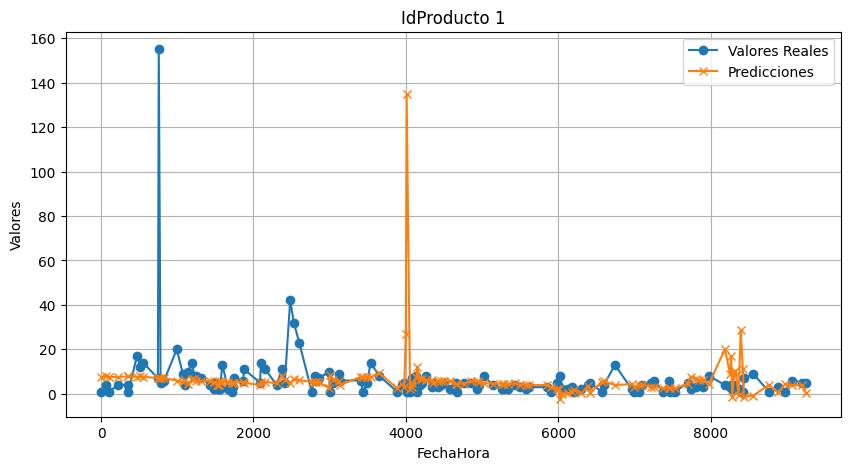

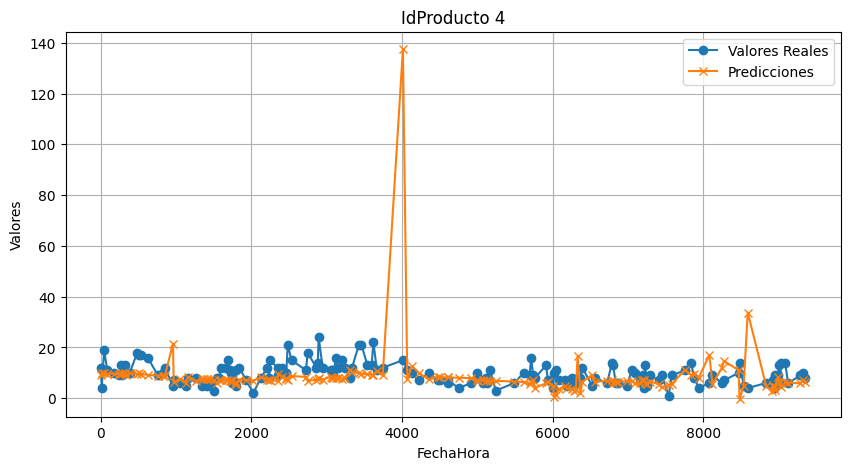

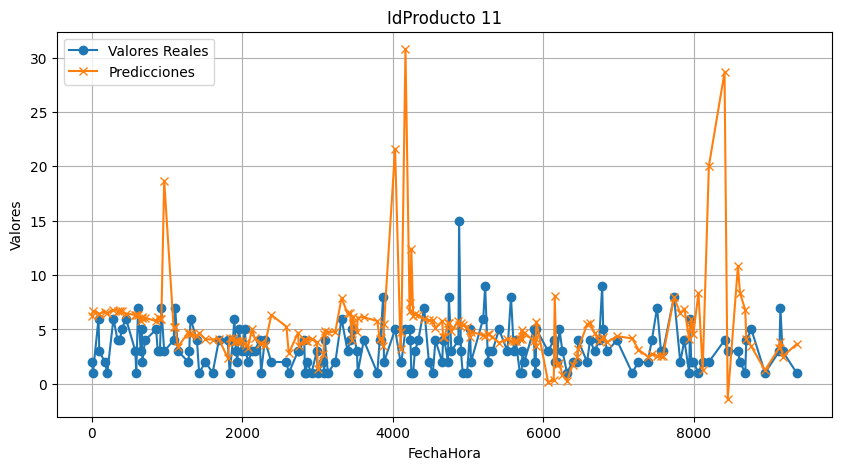

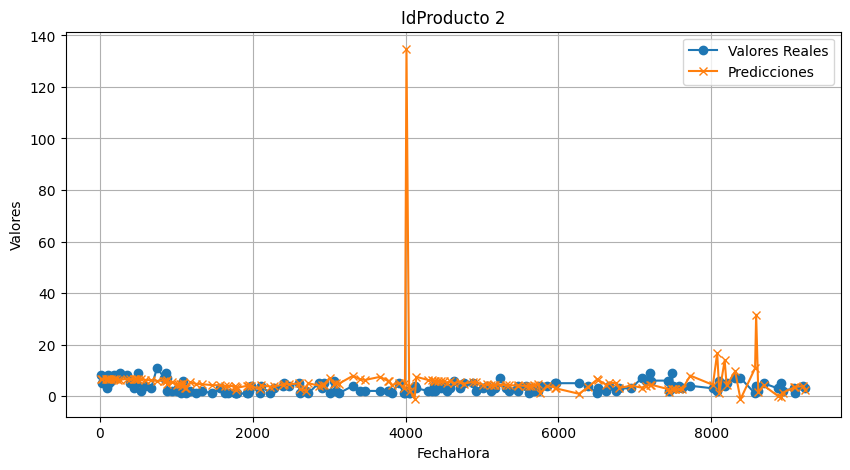

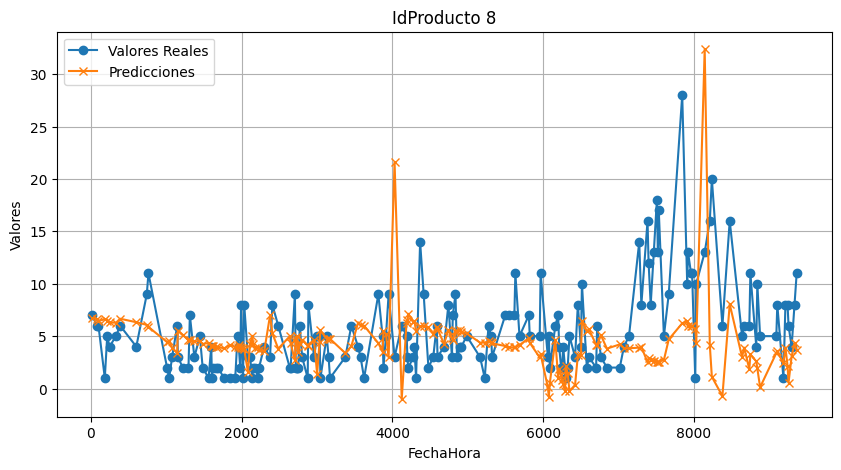

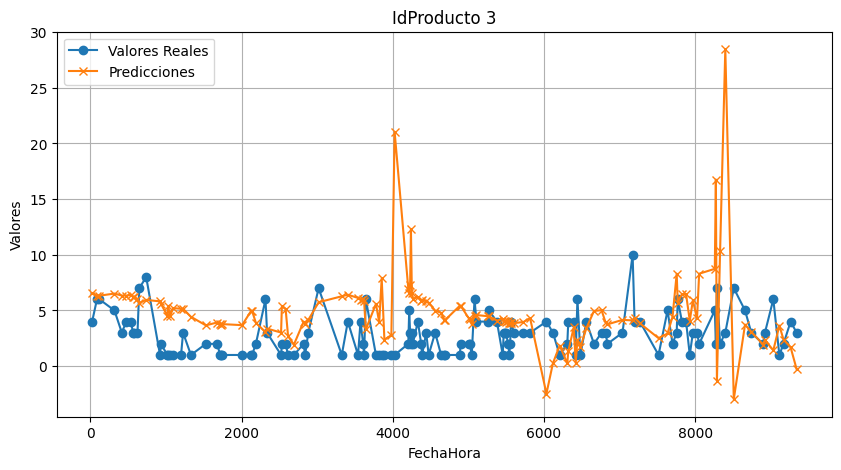

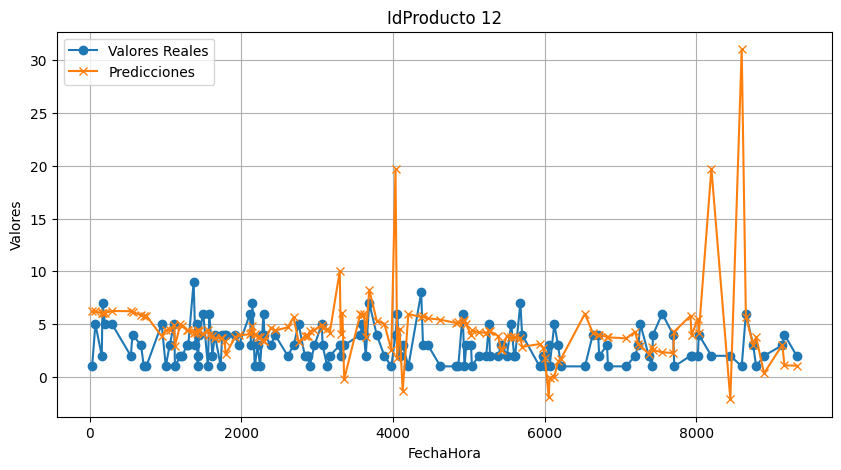

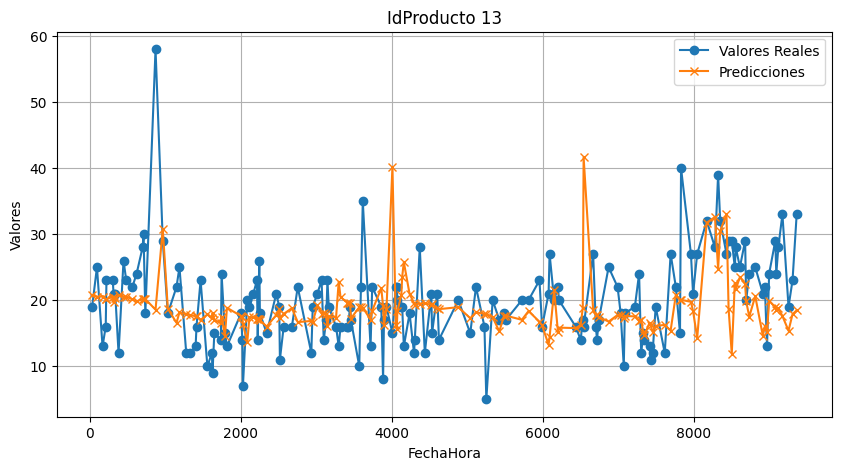

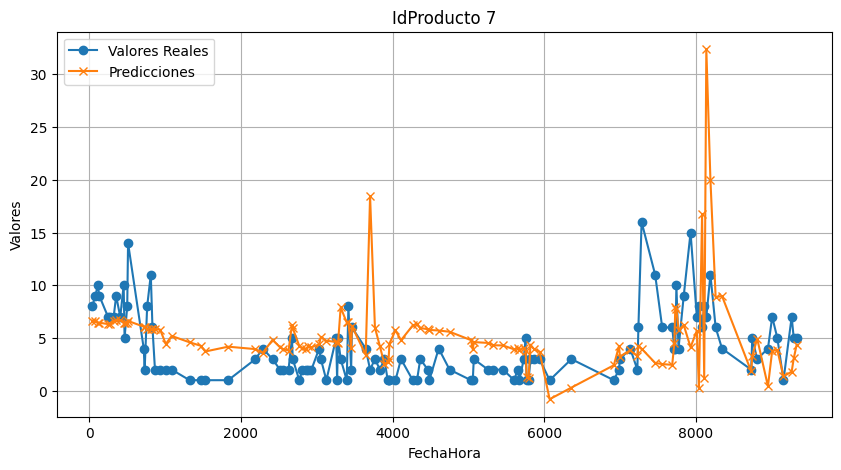

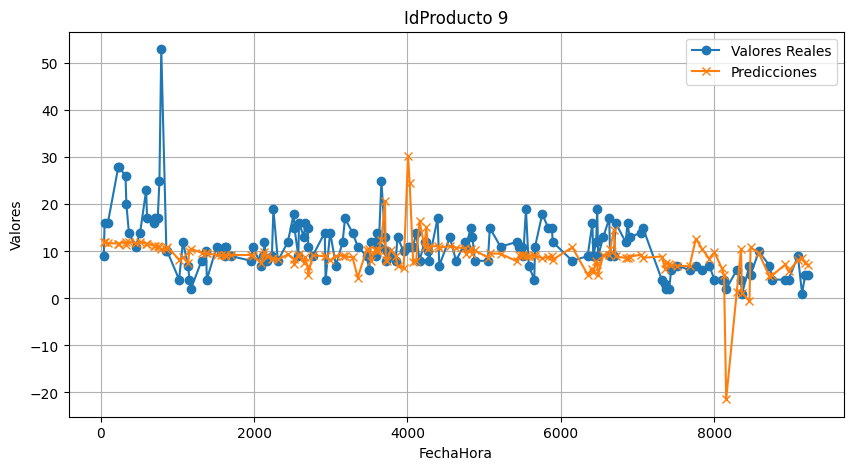

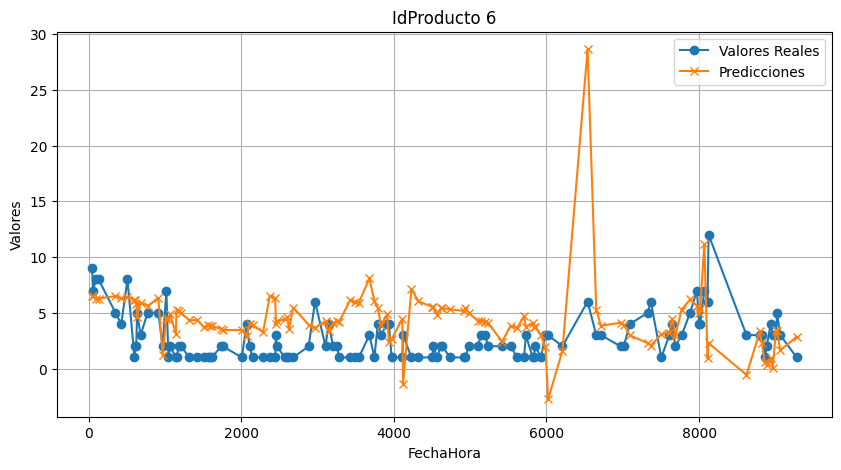

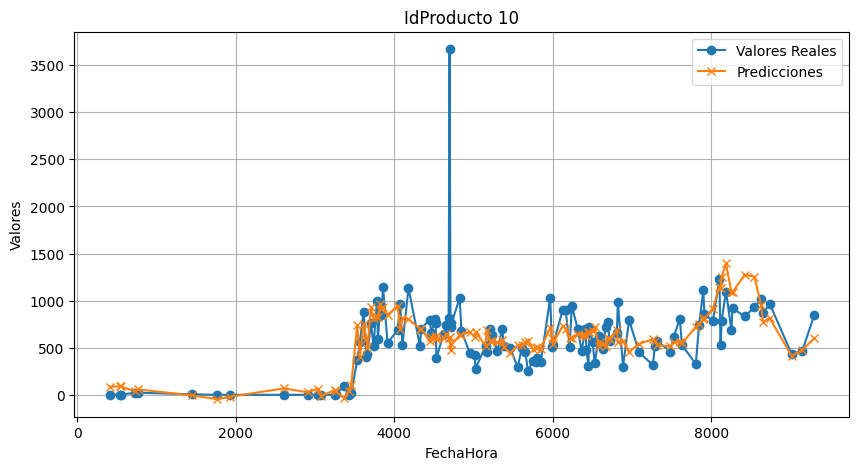

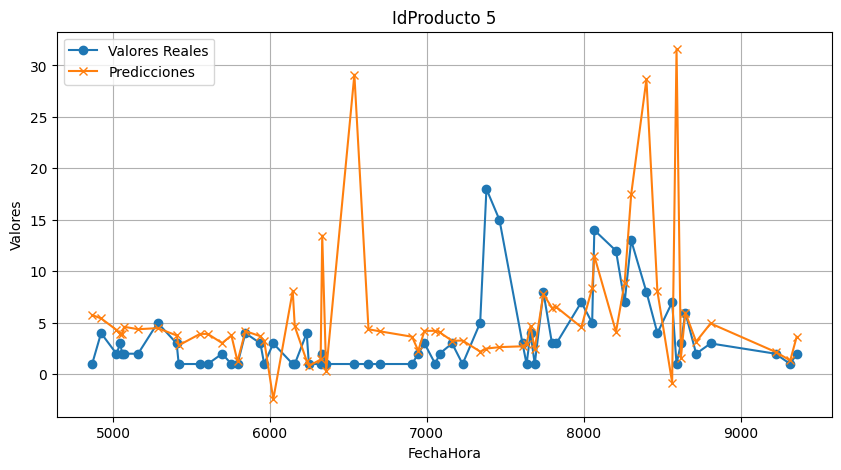

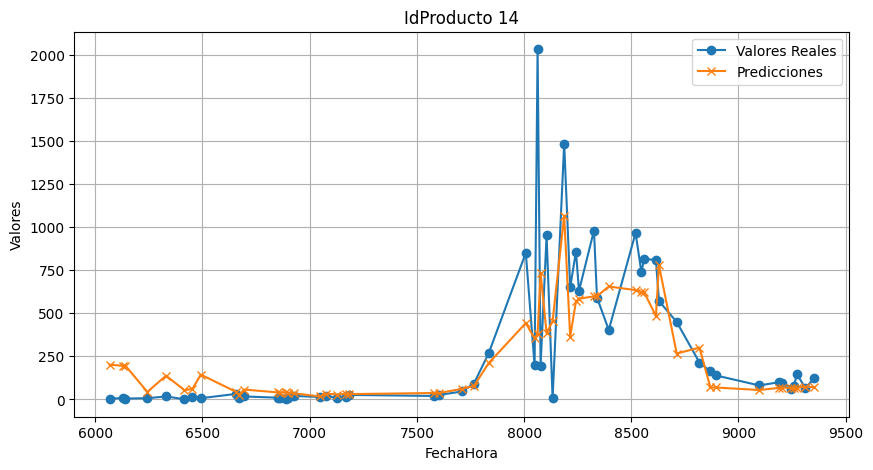

In [ ]:
predicciones_vs_reales = pd.DataFrame({'FechaHora': X_test.index, 'Valores Reales': y_test, 'Predicciones': y_pred_gb, 'IdProducto': X_test['IdProducto']})
predicciones_vs_reales = predicciones_vs_reales.sort_index()

def plot_for_id(predicciones_vs_reales, id_producto):
    df_id = predicciones_vs_reales[predicciones_vs_reales['IdProducto'] == id_producto]

    plt.figure(figsize=(10, 5))
    plt.plot(df_id['FechaHora'], df_id['Valores Reales'], marker='o', label='Valores Reales')
    plt.plot(df_id['FechaHora'], df_id['Predicciones'], marker='x', label='Predicciones')
    plt.title(f'IdProducto {id_producto}')
    plt.xlabel('FechaHora')
    plt.ylabel('Valores')
    plt.legend()
    plt.grid(True)
    plt.show()

id_productos_unicos = predicciones_vs_reales['IdProducto'].unique()

for id_producto in id_productos_unicos:
    plot_for_id(predicciones_vs_reales, id_producto)


In [ ]:
predicciones_vs_reales

,FechaHora,Valores Reales,Predicciones,IdProducto
0,0,1,7.465932,1
3,3,12,9.253746,4
8,8,2,6.266128,11
12,12,8,6.689009,2
14,14,4,9.820032,4
...,...,...,...,...
9357,9357,8,6.452464,4
9358,9358,2,3.646034,5
9361,9361,11,3.646034,8
9364,9364,1,3.646034,11


#SIMULACION PANDEMIA



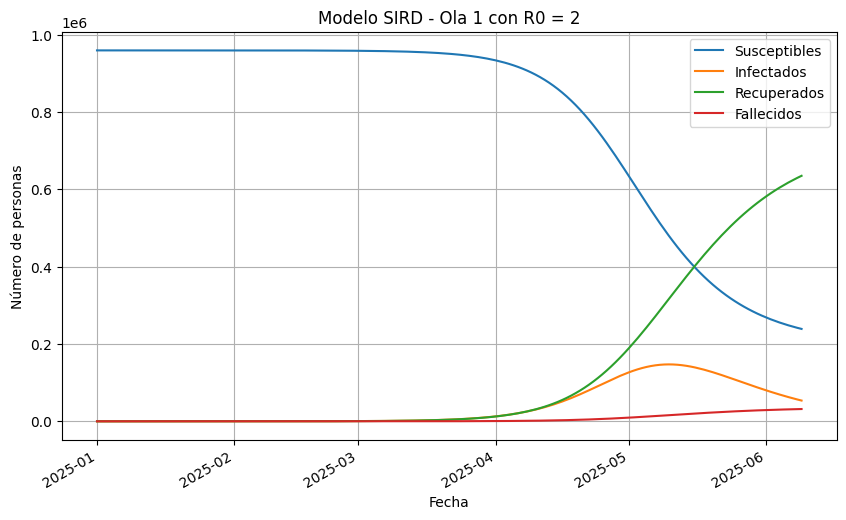

In [ ]:
N = 959801
R0 = 2
gamma = 1/10
mu = 0.005
beta = R0 * (gamma + mu)

I0 = 1
S0 = N - I0
R0 = 0
D0 = 0
y0 = [S0, I0, R0, D0]

def sird_model(y, t, N, beta, gamma, mu):
    S, I, R, D = y
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I - mu * I
    dRdt = gamma * I
    dDdt = mu * I
    return dSdt, dIdt, dRdt, dDdt

t = np.linspace(0, 160, 160)

sol = odeint(sird_model, y0, t, args=(N, beta, gamma, mu))
S, I, R, D = sol.T

start_date = datetime(2025, 1, 1)

dates = [start_date + timedelta(days=i) for i in range(len(t))]

plt.figure(figsize=(10, 6))
plt.plot(dates, S, label='Susceptibles')
plt.plot(dates, I, label='Infectados')
plt.plot(dates, R, label='Recuperados')
plt.plot(dates, D, label='Fallecidos')

plt.gcf().autofmt_xdate()

plt.xlabel('Fecha')
plt.ylabel('Número de personas')
plt.title('Modelo SIRD - Ola 1 con R0 = 2')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
start_date = datetime(2025, 1, 1)
dates = [start_date + timedelta(days=i) for i in range(len(t))]

data = {
    'FechaHora': dates,
    'num_susc': S,
    'num_casos_acum': I,
    'num_recu_acum': R,
    'num_def_acum': D
}

df_ola1 = pd.DataFrame(data)

df_ola1['num_casos'] = df_ola1['num_casos_acum'].diff().fillna(0).astype(int)
df_ola1['num_recu'] = df_ola1['num_recu_acum'].diff().fillna(0).astype(int)
df_ola1['num_def'] = df_ola1['num_def_acum'].diff().fillna(0).astype(int)

df_ola1['num_casos'] = df_ola1['num_casos'].abs()
df_ola1['num_recu'] = df_ola1['num_recu'].abs()
df_ola1['num_def'] = df_ola1['num_def'].abs()


df_ola1[['FechaHora', 'num_susc', 'num_casos', 'num_recu', 'num_def']]



,FechaHora,num_susc,num_casos,num_recu,num_def
0,2025-01-01,959800.000000,0,0,0
1,2025-01-02,959799.777112,0,0,0
2,2025-01-03,959799.529384,0,0,0
3,2025-01-04,959799.254048,0,0,0
4,2025-01-05,959798.948028,0,0,0
...,...,...,...,...,...
155,2025-06-05,251992.705804,3369,6812,340
156,2025-06-06,248445.566126,3256,6479,323
157,2025-06-07,245120.917440,3140,6157,307
158,2025-06-08,242004.931680,3023,5847,292


In [ ]:
suma_def = df_ola1['num_def'].sum()
I_final = df_ola1['num_casos'].iloc[-1]

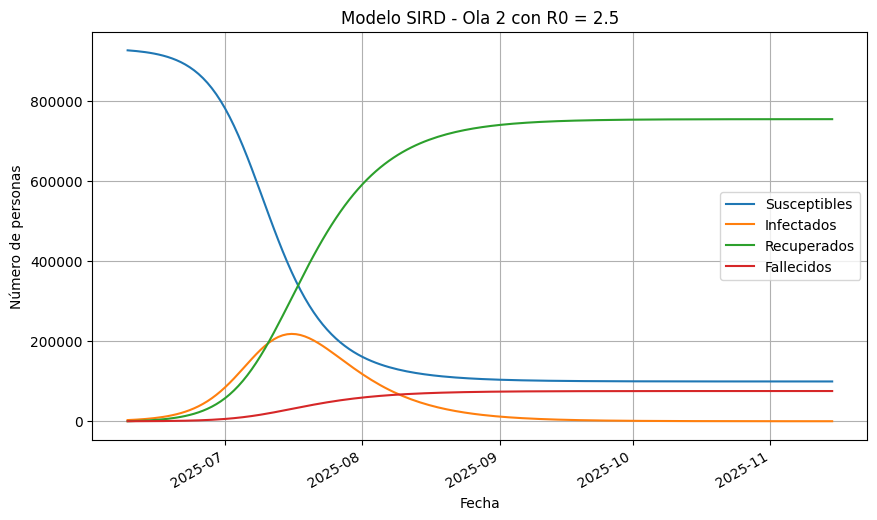

In [ ]:

N_new = N - suma_def
I0_new = I_final
S0_new = N_new - I0_new
R0_new = 0
D0_new = 0
y0_new = [S0_new, I0_new, R0_new, D0_new]

R0_new_value = 2.5
mu_new = 0.01
beta_new = R0_new_value * (gamma + mu_new)

def new_model(y, t, N, beta, gamma, mu):
    S, I, R, D = y
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I - mu * I
    dRdt = gamma * I
    dDdt = mu * I
    return dSdt, dIdt, dRdt, dDdt


t = np.linspace(0, 160, 160)

sol_new = odeint(new_model, y0_new, t, args=(N_new, beta_new, gamma, mu_new))
S_new, I_new, R_new, D_new = sol_new.T

start_date = datetime(2025, 6, 9)

dates = [start_date + timedelta(days=i) for i in range(len(t))]

plt.figure(figsize=(10, 6))
plt.plot(dates, S_new, label='Susceptibles')
plt.plot(dates, I_new, label='Infectados')
plt.plot(dates, R_new, label='Recuperados')
plt.plot(dates, D_new, label='Fallecidos')

plt.gcf().autofmt_xdate()

plt.xlabel('Fecha')
plt.ylabel('Número de personas')
plt.title('Modelo SIRD - Ola 2 con R0 = 2.5')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
start_date = datetime(2025, 6, 9)
dates = [start_date + timedelta(days=i) for i in range(len(t))]

data = {
    'FechaHora': dates,
    'num_susc': S_new,
    'num_casos_acum': I_new,
    'num_recu_acum': R_new,
    'num_def_acum': D_new
}

df_ola2 = pd.DataFrame(data)

df_ola2['num_casos'] = df_ola2['num_casos_acum'].diff().fillna(0).astype(int)
df_ola2['num_recu'] = df_ola2['num_recu_acum'].diff().fillna(0).astype(int)
df_ola2['num_def'] = df_ola2['num_def_acum'].diff().fillna(0).astype(int)

df_ola2['num_casos'] = df_ola2['num_casos'].abs()
df_ola2['num_recu'] = df_ola2['num_recu'].abs()
df_ola2['num_def'] = df_ola2['num_def'].abs()


df_ola2 = df_ola2.drop(df_ola2.index[0])
df_ola2[['FechaHora', 'num_susc', 'num_casos', 'num_recu', 'num_def']]



,FechaHora,num_susc,num_casos,num_recu,num_def
1,2025-06-10,924328.082448,521,317,31
2,2025-06-11,923302.080119,613,374,37
3,2025-06-12,922093.970343,722,441,44
4,2025-06-13,920672.252511,848,520,52
5,2025-06-14,919000.295288,997,613,61
...,...,...,...,...,...
155,2025-11-11,99224.607208,3,3,0
156,2025-11-12,99223.557793,2,3,0
157,2025-11-13,99222.590142,2,3,0
158,2025-11-14,99221.697885,2,3,0


In [ ]:
suma_def2 = df_ola2['num_def'].sum()
I_final2 = df_ola2['num_casos'].iloc[-1]

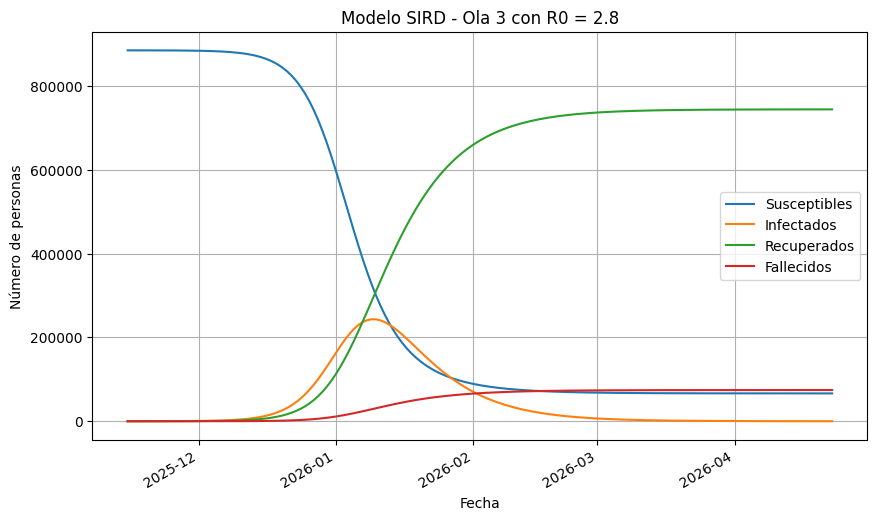

In [ ]:
I_final2 = I_new[-1]

N_third = N - suma_def2  # Nueva población total es N - número total de fallecidos del segundo modelo
I0_third = I_final2    # Nuevo número inicial de infectados es el número final de infectados del segundo modelo
S0_third = N_third - I0_third
R0_third = 0
D0_third = 0
y0_third = [S0_third, I0_third, R0_third, D0_third]

R0_third_value = 2.8
beta_third = R0_third_value * (gamma + mu_new)

def third_model(y, t, N, beta, gamma, mu):
    S, I, R, D = y
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I - mu_new * I
    dRdt = gamma * I
    dDdt = mu * I
    return dSdt, dIdt, dRdt, dDdt

t = np.linspace(0, 160, 160)

sol_third = odeint(third_model, y0_third, t, args=(N_third, beta_third, gamma, mu_new))
S_third, I_third, R_third, D_third = sol_third.T

start_date = datetime(2025, 11, 15)

dates = [start_date + timedelta(days=i) for i in range(len(t))]

plt.figure(figsize=(10, 6))
plt.plot(dates, S_third, label='Susceptibles')
plt.plot(dates, I_third, label='Infectados')
plt.plot(dates, R_third, label='Recuperados')
plt.plot(dates, D_third, label='Fallecidos')

plt.gcf().autofmt_xdate()

plt.xlabel('Fecha')
plt.ylabel('Número de personas')
plt.title('Modelo SIRD - Ola 3 con R0 = 2.8')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
start_date = datetime(2025, 11, 15)
dates = [start_date + timedelta(days=i) for i in range(len(t))]

data = {
    'FechaHora': dates,
    'num_susc': S_third,
    'num_casos_acum': I_third,
    'num_recu_acum': R_third,
    'num_def_acum': D_third
}

df_ola3 = pd.DataFrame(data)

df_ola3['num_casos'] = df_ola3['num_casos_acum'].diff().fillna(0).astype(int)
df_ola3['num_recu'] = df_ola3['num_recu_acum'].diff().fillna(0).astype(int)
df_ola3['num_def'] = df_ola3['num_def_acum'].diff().fillna(0).astype(int)

df_ola3['num_casos'] = df_ola3['num_casos'].abs()
df_ola3['num_recu'] = df_ola3['num_recu'].abs()
df_ola3['num_def'] = df_ola3['num_def'].abs()


df_ola3 = df_ola3.drop(df_ola3.index[0])
df_ola3[['FechaHora', 'num_susc', 'num_casos', 'num_recu', 'num_def']]



,FechaHora,num_susc,num_casos,num_recu,num_def
1,2025-11-16,884493.146708,5,2,0
2,2025-11-17,884481.972232,7,3,0
3,2025-11-18,884468.334410,8,4,0
4,2025-11-19,884451.690346,10,5,0
5,2025-11-20,884431.377557,13,6,0
...,...,...,...,...,...
155,2026-04-19,66383.799065,8,9,0
156,2026-04-20,66381.771106,7,8,0
157,2026-04-21,66379.912980,6,8,0
158,2026-04-22,66378.210459,6,7,0


#GENERAR NUEVO DATA FRAME COMPELTO

In [ ]:
df_pandemia = pd.concat([df_ola1, df_ola2, df_ola3], axis=0, ignore_index=True)
df_pandemia

,FechaHora,num_susc,num_casos_acum,num_recu_acum,num_def_acum,num_casos,num_recu,num_def
0,2025-01-01,959800.000000,1.000000,0.000000,0.000000,0,0,0
1,2025-01-02,959799.777112,1.111444,0.106137,0.005307,0,0,0
2,2025-01-03,959799.529384,1.235308,0.224103,0.011205,0,0,0
3,2025-01-04,959799.254048,1.372975,0.355216,0.017761,0,0,0
4,2025-01-05,959798.948028,1.525985,0.500940,0.025047,0,0,0
...,...,...,...,...,...,...,...,...
473,2026-04-19,66383.799065,91.051979,743685.589959,74368.558996,8,9,0
474,2026-04-20,66381.771106,83.429262,743694.363302,74369.436330,7,8,0
475,2026-04-21,66379.912980,76.444653,743702.402152,74370.240215,6,8,0
476,2026-04-22,66378.210459,70.044745,743709.767996,74370.976800,6,7,0


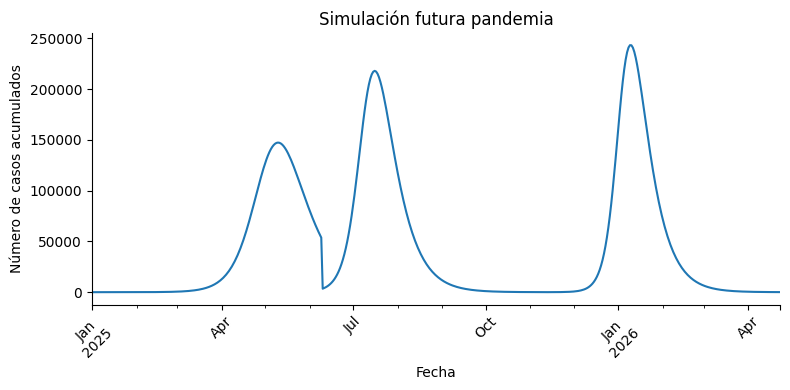

In [ ]:
df_pandemia.set_index('FechaHora', inplace=True)

plt.figure(figsize=(8, 4))
df_pandemia['num_casos_acum'].plot(kind='line', title='Simulación futura pandemia')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.xlabel('Fecha')
plt.ylabel('Número de casos acumulados')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
fecha_hora_inicial = '2025-01-01 '
fechas_siguientes = pd.date_range(start=fecha_hora_inicial, periods=478, freq='D')
dataframes = []

for fecha in fechas_siguientes:
    fechas = [fecha] * 14
    id_productos = range(1, 15)
    data = {'FechaHora': fechas, 'IdProducto': id_productos}
    df_dia = pd.DataFrame(data)
    dataframes.append(df_dia)

df2 = pd.concat(dataframes, ignore_index=True)

df2

,FechaHora,IdProducto
0,2025-01-01,1
1,2025-01-01,2
2,2025-01-01,3
3,2025-01-01,4
4,2025-01-01,5
...,...,...
6687,2026-04-23,10
6688,2026-04-23,11
6689,2026-04-23,12
6690,2026-04-23,13


In [ ]:

df2['FechaHora'] = pd.to_datetime(df2['FechaHora'])

df_unificado = pd.merge(df_pandemia, df2, on='FechaHora', how='inner')
df_unificado = df_unificado.set_index('FechaHora')
df_unificado

,num_susc,num_casos_acum,num_recu_acum,num_def_acum,num_casos,num_recu,num_def,IdProducto
FechaHora,,,,,,,,
2025-01-01,959800.000000,1.000000,0.000000,0.000000,0,0,0,1
2025-01-01,959800.000000,1.000000,0.000000,0.000000,0,0,0,2
2025-01-01,959800.000000,1.000000,0.000000,0.000000,0,0,0,3
2025-01-01,959800.000000,1.000000,0.000000,0.000000,0,0,0,4
2025-01-01,959800.000000,1.000000,0.000000,0.000000,0,0,0,5
...,...,...,...,...,...,...,...,...
2026-04-23,66376.650512,64.180597,743716.517174,74371.651717,5,6,0,10
2026-04-23,66376.650512,64.180597,743716.517174,74371.651717,5,6,0,11
2026-04-23,66376.650512,64.180597,743716.517174,74371.651717,5,6,0,12


#NUEVAS PREDICCIONES

In [ ]:
df_unificado['Year'] = df_unificado.index.year
df_unificado['Month'] = df_unificado.index.month
df_unificado['Day'] = df_unificado.index.day

id_productos_unicos = df_unificado['IdProducto'].unique()

predicciones_totales = []

for id_producto in id_productos_unicos:
    df_id = df_unificado[df_unificado['IdProducto'] == id_producto]

    X_new = df_id[['num_casos', 'num_def', 'num_recu', 'num_susc', 'IdProducto', 'Year', 'Month', 'Day']]

    y_pred_new = best_model.predict(X_new)

    y_pred_new = y_pred_new.clip(min=0)

    df_id['Predicciones'] = y_pred_new

    predicciones_totales.append(df_id)

df_predicciones_totales = pd.concat(predicciones_totales)

df_predicciones_totales

<ipython-input-32-a352770a01ff>:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_id['Predicciones'] = y_pred_new
<ipython-input-32-a352770a01ff>:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_id['Predicciones'] = y_pred_new
<ipython-input-32-a352770a01ff>:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide

,num_susc,num_casos_acum,num_recu_acum,num_def_acum,num_casos,num_recu,num_def,IdProducto,Year,Month,Day,Predicciones
FechaHora,,,,,,,,,,,,
2025-01-01,959800.000000,1.000000,0.000000,0.000000,0,0,0,1,2025,1,1,4.638869
2025-01-02,959799.777112,1.111444,0.106137,0.005307,0,0,0,1,2025,1,2,5.043793
2025-01-03,959799.529384,1.235308,0.224103,0.011205,0,0,0,1,2025,1,3,5.018565
2025-01-04,959799.254048,1.372975,0.355216,0.017761,0,0,0,1,2025,1,4,5.007722
2025-01-05,959798.948028,1.525985,0.500940,0.025047,0,0,0,1,2025,1,5,5.007722
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-19,66383.799065,91.051979,743685.589959,74368.558996,8,9,0,14,2026,4,19,111.341911
2026-04-20,66381.771106,83.429262,743694.363302,74369.436330,7,8,0,14,2026,4,20,111.341911
2026-04-21,66379.912980,76.444653,743702.402152,74370.240215,6,8,0,14,2026,4,21,111.300390


In [ ]:
df_suma_predicciones = df_predicciones_totales.groupby(df_predicciones_totales.index)['Predicciones'].sum().reset_index()
df_suma_predicciones

,FechaHora,Predicciones
0,2025-01-01,381.158072
1,2025-01-02,546.993366
2,2025-01-03,630.738697
3,2025-01-04,645.983960
4,2025-01-05,645.983960
...,...,...
473,2026-04-19,710.694494
474,2026-04-20,710.694494
475,2026-04-21,722.159517
476,2026-04-22,728.507601


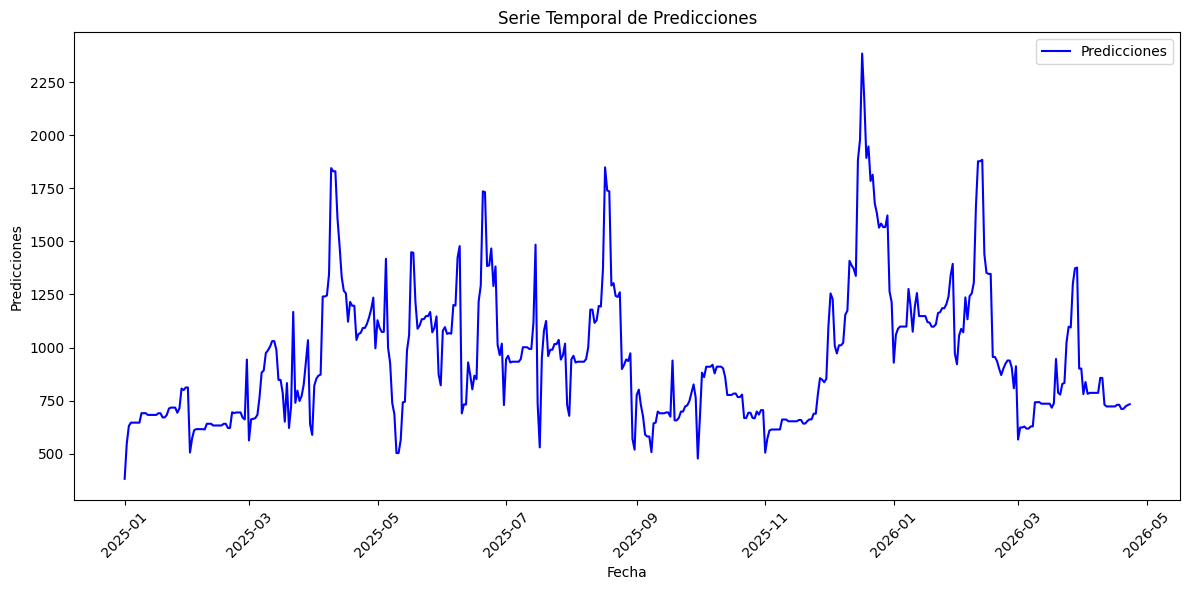

In [ ]:
df_suma_predicciones.set_index('FechaHora', inplace=True)
plt.figure(figsize=(12, 6))
plt.plot(df_suma_predicciones.index, df_suma_predicciones['Predicciones'], linestyle='-', color='b', label='Predicciones')
plt.title('Serie Temporal de Predicciones')
plt.xlabel('Fecha')
plt.ylabel('Predicciones')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

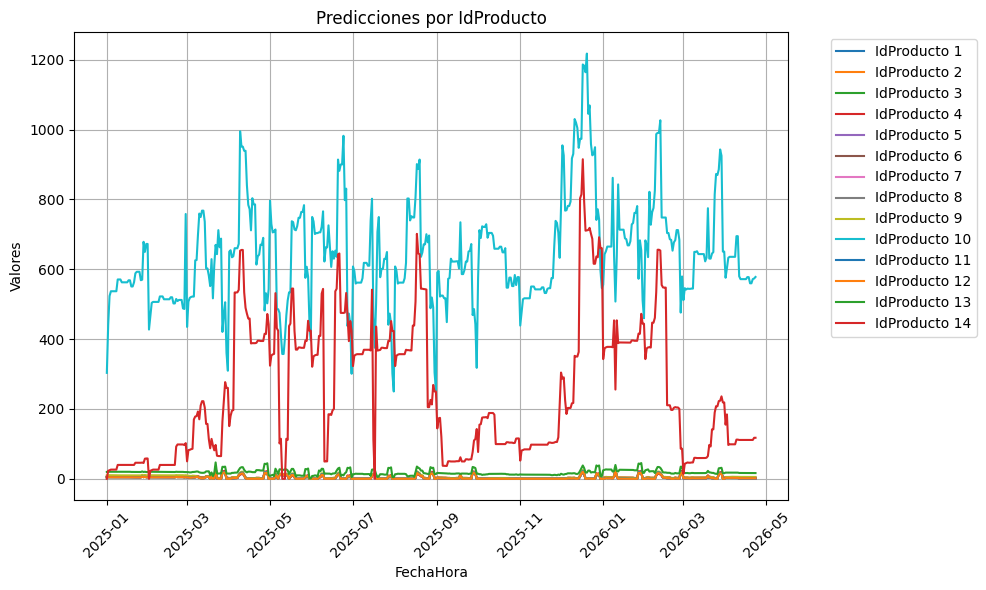

In [ ]:
import matplotlib.pyplot as plt

df_predicciones_totales = df_predicciones_totales.sort_index()

plt.figure(figsize=(10, 6))

for id_producto, group in df_predicciones_totales.groupby('IdProducto'):
    plt.plot(group.index, group['Predicciones'], linestyle='-', label=f'IdProducto {id_producto}')

plt.xlabel('FechaHora')
plt.ylabel('Valores')
plt.title('Predicciones por IdProducto')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


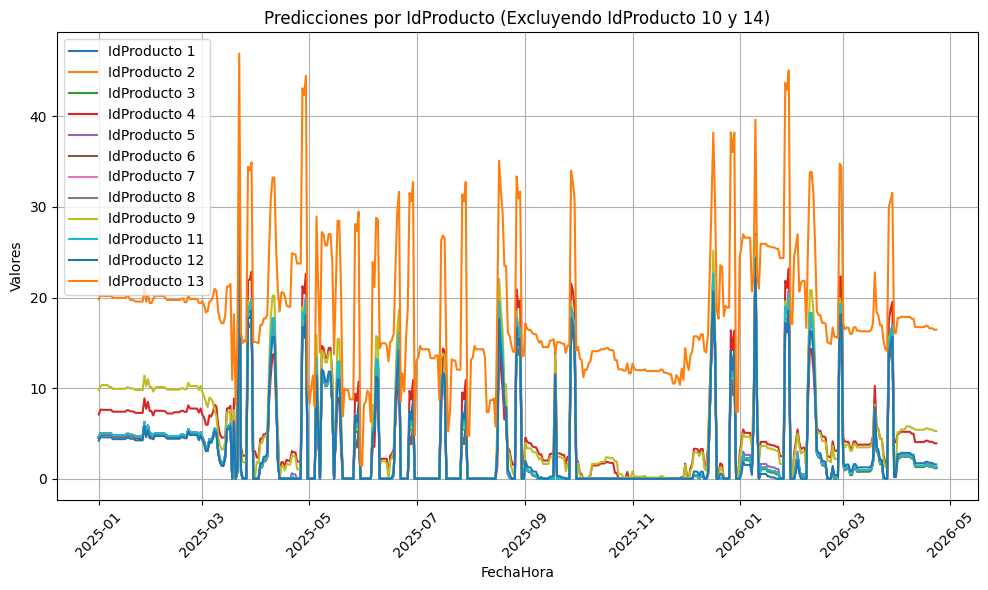

In [ ]:
df_predicciones_totales = df_predicciones_totales.sort_index()

df_filtrado = df_predicciones_totales[~df_predicciones_totales['IdProducto'].isin([10, 14])]

plt.figure(figsize=(10, 6))

for id_producto, group in df_filtrado.groupby('IdProducto'):
    plt.plot(group.index, group['Predicciones'],  linestyle='-', label=f'IdProducto {id_producto}')

plt.xlabel('FechaHora')
plt.ylabel('Valores')
plt.title('Predicciones por IdProducto (Excluyendo IdProducto 10 y 14)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
for id_producto, group in df_predicciones_totales.groupby('IdProducto'):
    print(f"Predicciones y Num Casos para IdProducto {id_producto}:")
    print(group)
    print()

Predicciones y Num Casos para IdProducto 1:
                 num_susc  num_casos_acum  num_recu_acum  num_def_acum  \
FechaHora                                                                
2025-01-01  959800.000000        1.000000       0.000000      0.000000   
2025-01-02  959799.777112        1.111444       0.106137      0.005307   
2025-01-03  959799.529384        1.235308       0.224103      0.011205   
2025-01-04  959799.254048        1.372975       0.355216      0.017761   
2025-01-05  959798.948028        1.525985       0.500940      0.025047   
...                   ...             ...            ...           ...   
2026-04-19   66383.799065       91.051979  743685.589959  74368.558996   
2026-04-20   66381.771106       83.429262  743694.363302  74369.436330   
2026-04-21   66379.912980       76.444653  743702.402152  74370.240215   
2026-04-22   66378.210459       70.044745  743709.767996  74370.976800   
2026-04-23   66376.650512       64.180597  743716.517174  74371.6517

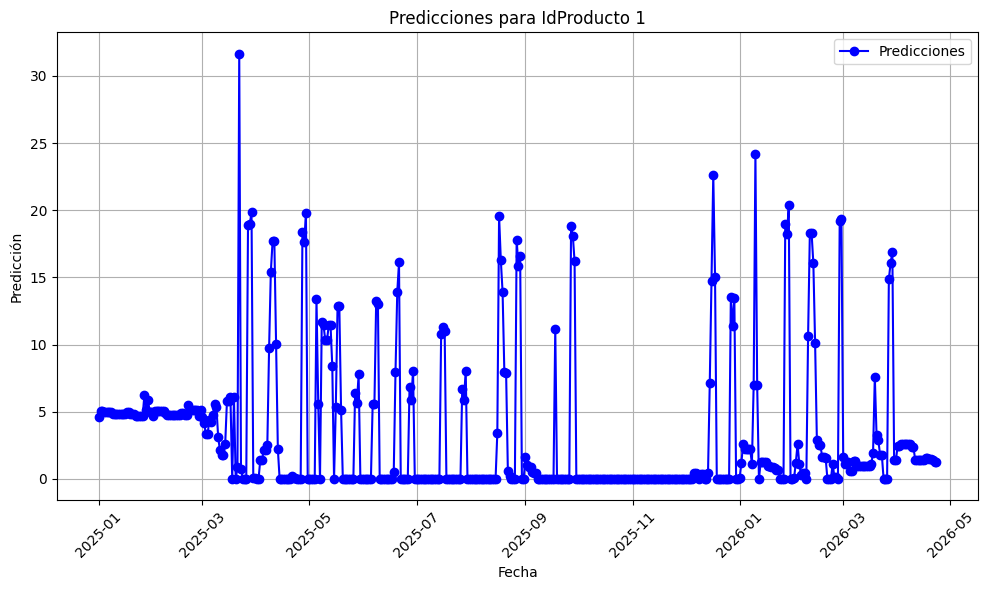

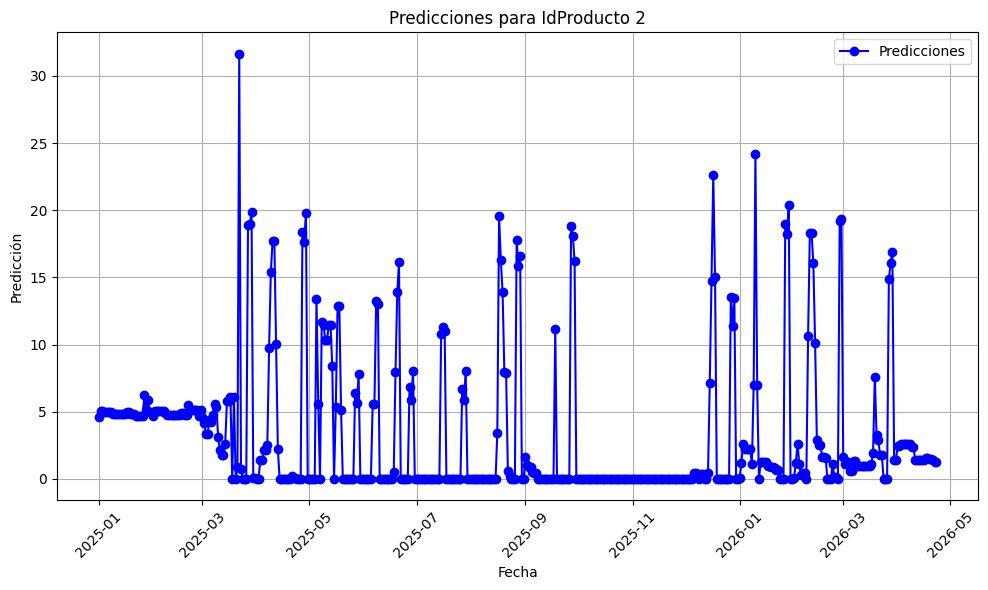

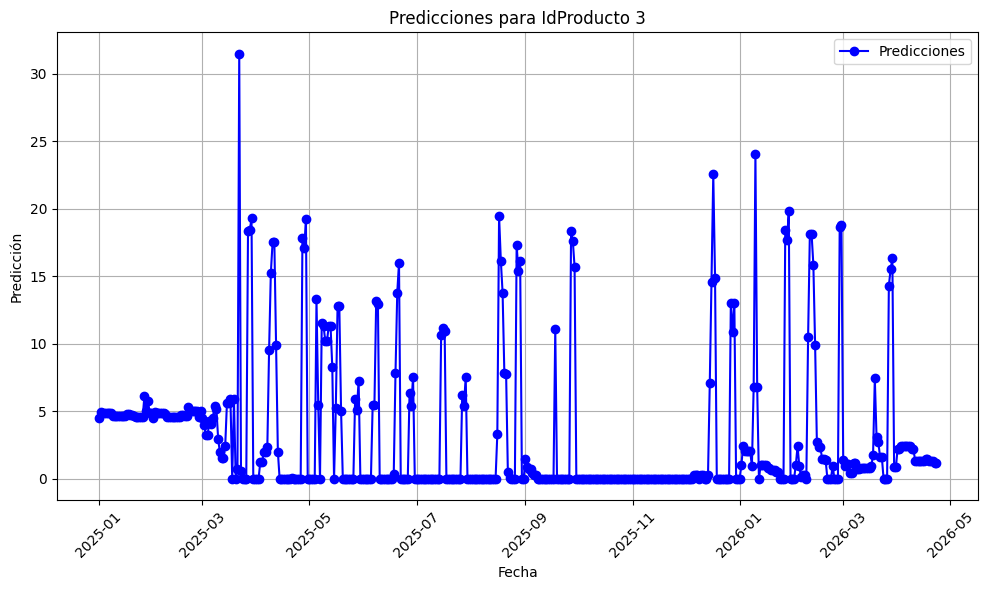

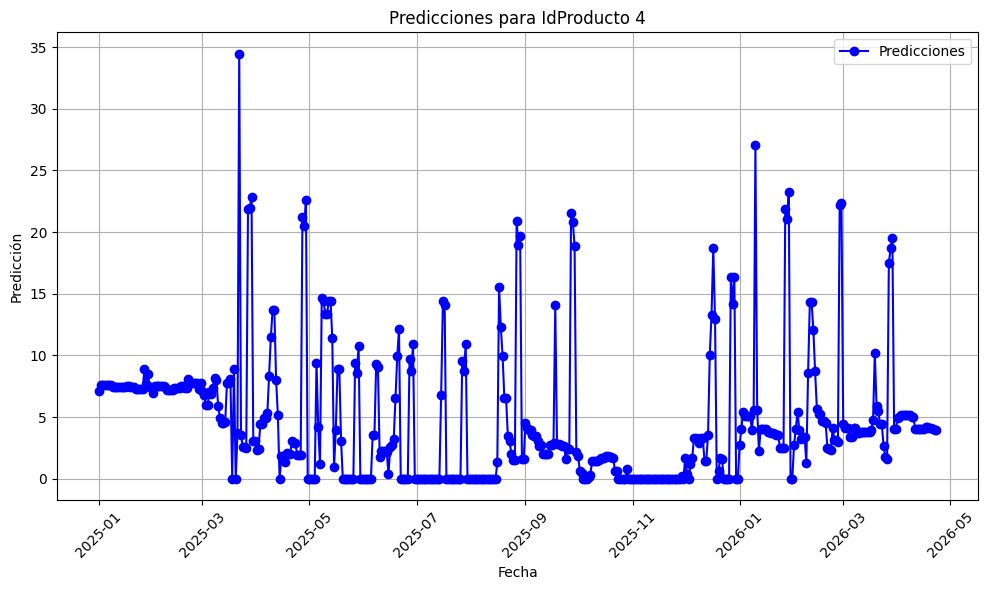

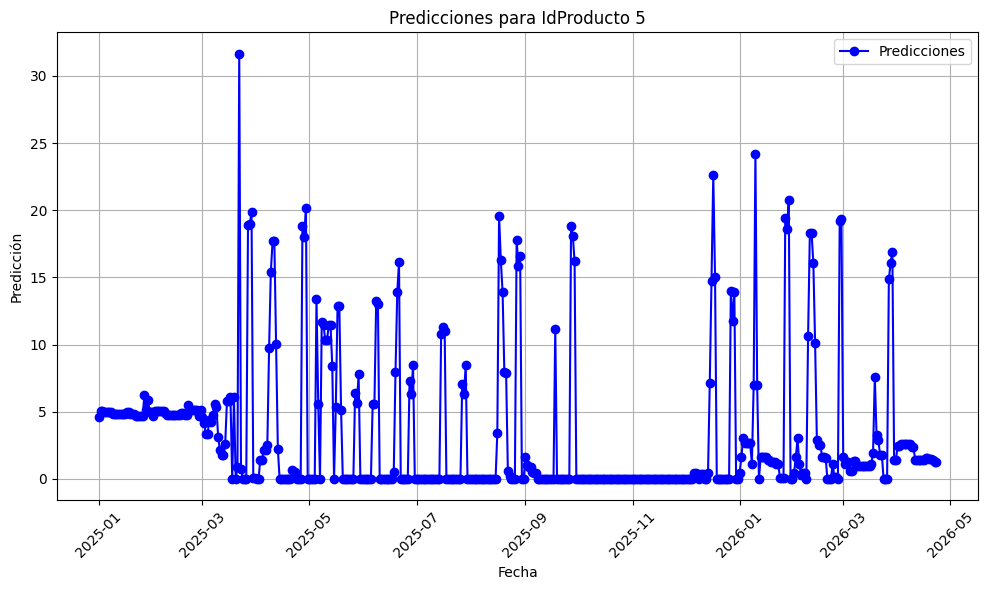

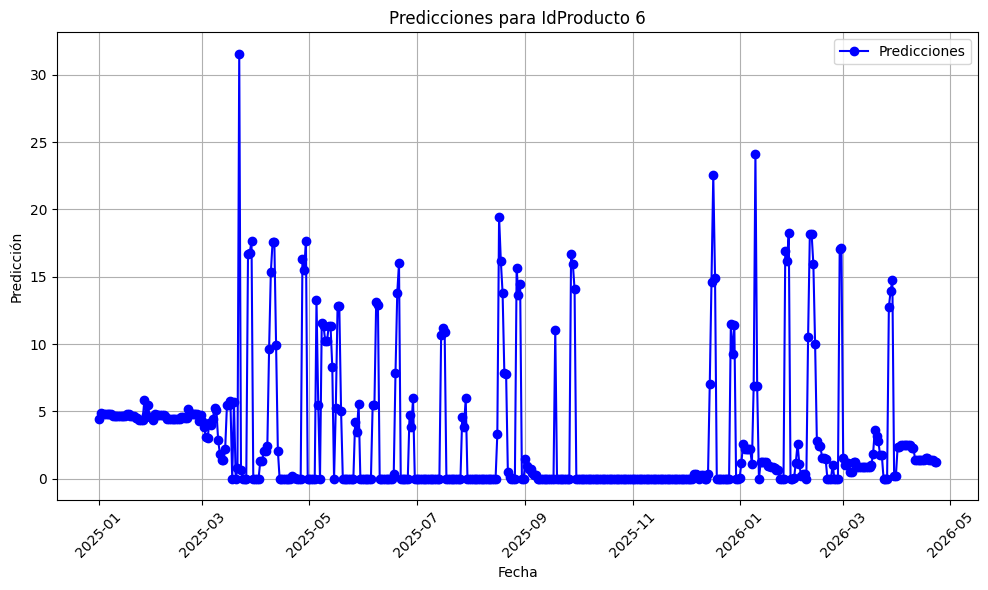

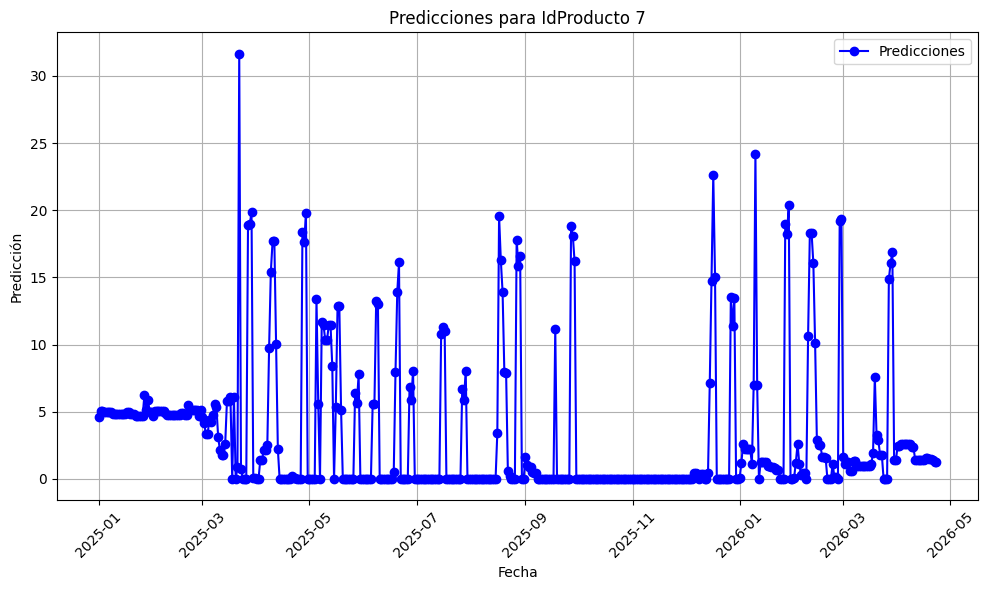

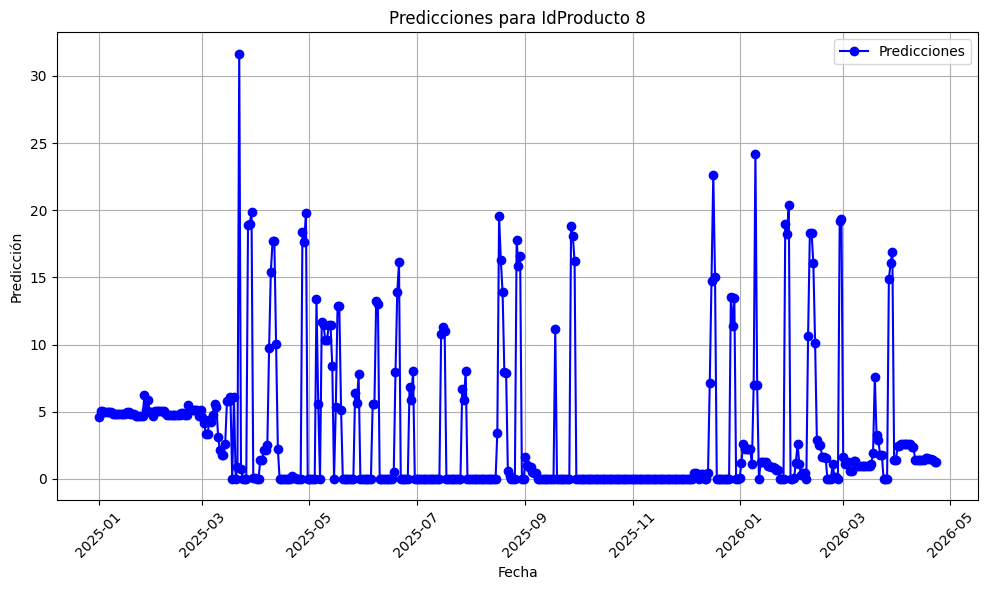

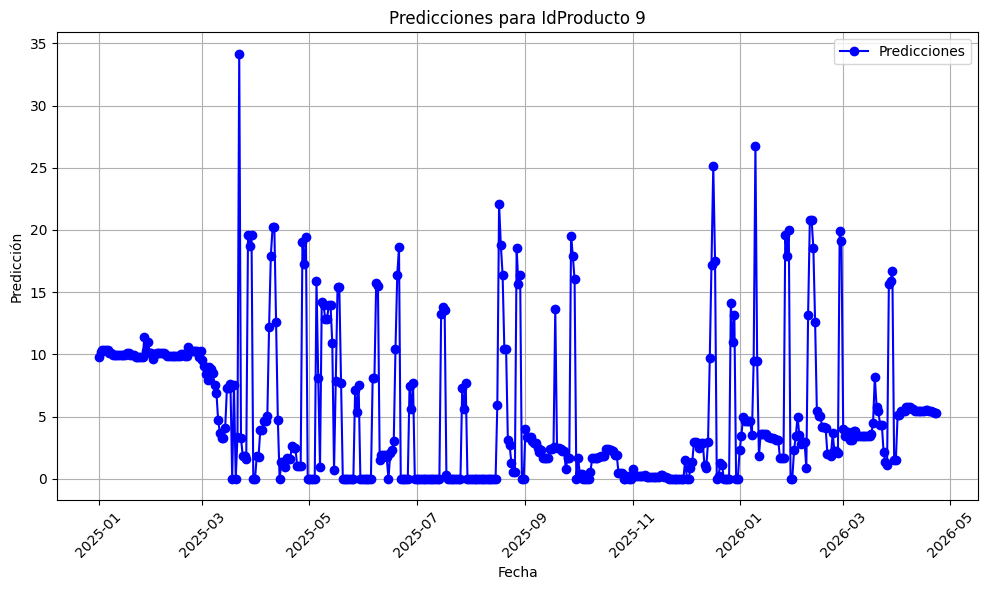

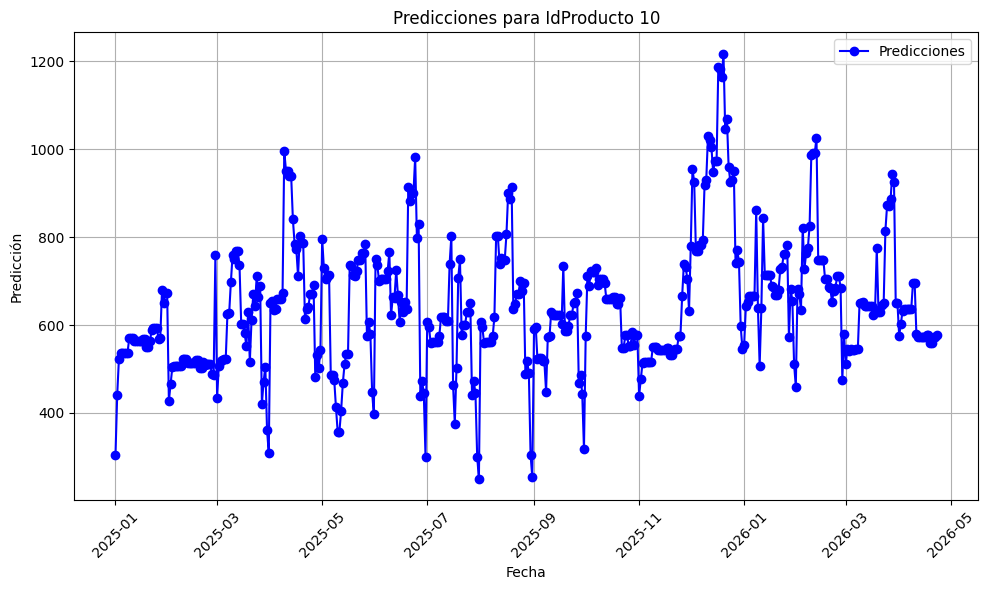

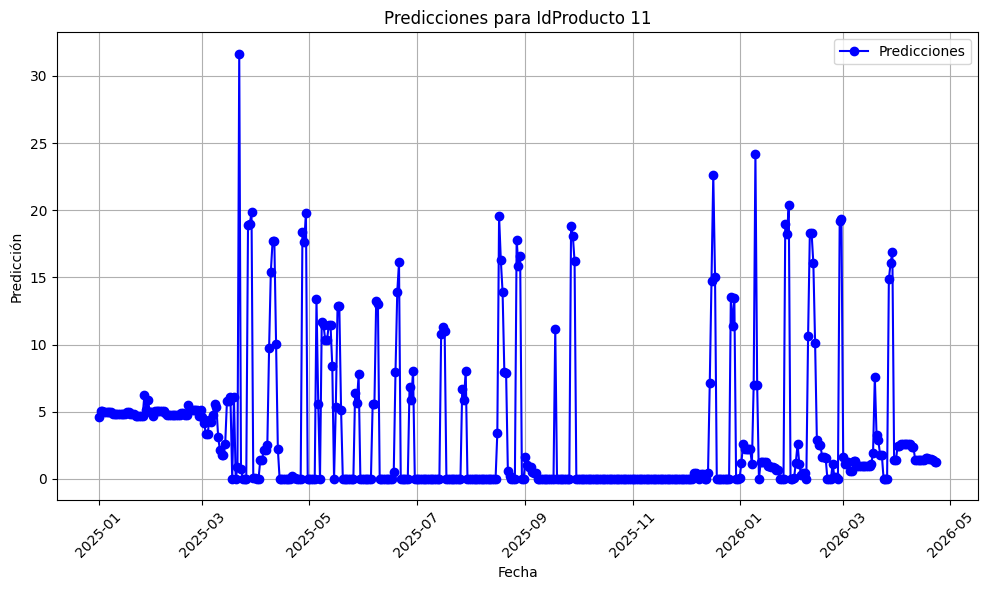

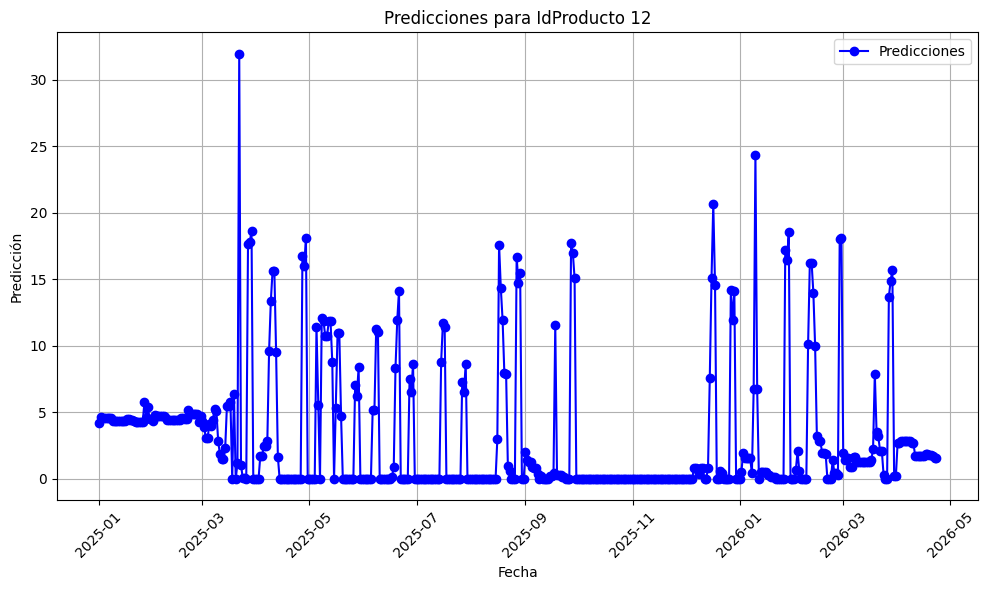

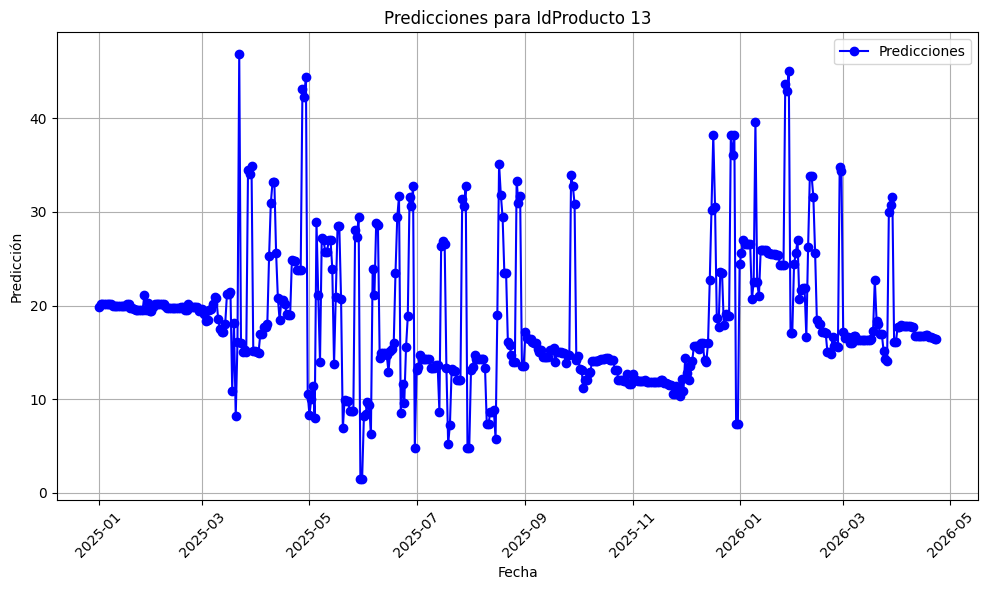

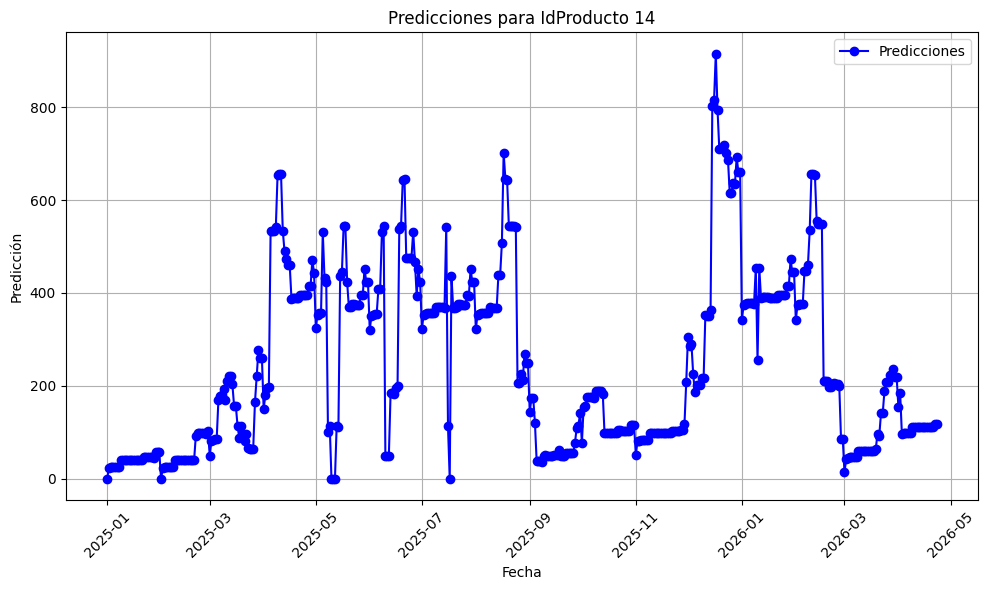

In [ ]:
for id_producto, group in df_predicciones_totales.groupby('IdProducto'):

    plt.figure(figsize=(10, 6))
    plt.plot(group.index, group['Predicciones'], marker='o', linestyle='-', color='b', label='Predicciones')
    plt.title(f'Predicciones para IdProducto {id_producto}')
    plt.xlabel('Fecha')
    plt.ylabel('Predicción')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
fechas_interes = ['2026-01-01', '2025-08-29']
df_filtro = df_predicciones_totales[df_predicciones_totales.index.strftime('%Y-%m-%d').isin(fechas_interes)]

for id_producto, group in df_filtro.groupby('IdProducto'):
    print(f"Predicciones y Num Casos para IdProducto {id_producto}:")
    print(group)
    print()


Predicciones y Num Casos para IdProducto 1:
                 num_susc  num_casos_acum  num_recu_acum  num_def_acum  \
FechaHora                                                                
2025-08-29  104751.336832    14632.712539  735199.955117  73519.995512   
2026-01-01  597610.808333   163057.152916  112600.944319  11260.094432   

            num_casos  num_recu  num_def  IdProducto  Year  Month  Day  \
FechaHora                                                                
2025-08-29       1209      1532      153           1  2025      8   29   
2026-01-01      16194     15594     1559           1  2026      1    1   

            Predicciones  
FechaHora                 
2025-08-29     16.617670  
2026-01-01      0.042008  

Predicciones y Num Casos para IdProducto 2:
                 num_susc  num_casos_acum  num_recu_acum  num_def_acum  \
FechaHora                                                                
2025-08-29  104751.336832    14632.712539  735199.955117  735